In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import malariagen_data

In [ ]:
# Init  API and load metadata
adir1 = malariagen_data.Adir1()
df_samples = adir1.sample_metadata()

In [8]:
# Function for plotting map
def plot_sample_map(bbox, df, colour_factor):
    # Define colors by country
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    countries = df_samples['country'].unique()
    #color_map = dict(zip(countries, plt.cm.tab10.colors[:len(countries)]))
    
    # Create the plot
    fig = plt.figure(figsize=(6, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(bbox)
    
    # Add features
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='#f0f0f0')
    ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='#c6dbef')
    ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor='gray')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.RIVERS, edgecolor='#3182bd')
    
    # Add country name labels
    country_coords = {
        'Thailand': (100.5, 15.0),
        'Bangladesh': (92.0, 23.2),
        'Cambodia': (105.0, 14.5)
    }
    
    for country, (lon, lat) in country_coords.items():
        ax.text(lon, lat, country, 
                transform=ccrs.PlateCarree(),
                fontsize=14, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    # Create colourmap    
    unique_rows = list(df_samples[colour_factor].unique())
    tab10_colors = plt.get_cmap('Set1').colors
    colourmap = {row: tab10_colors[i] for i, row in enumerate(unique_rows)}
    
    # Plot each point colored by country
    for _, row in df.iterrows():
        ax.scatter(row['longitude'], row['latitude'],
                   color=colourmap[row[colour_factor]],
                   s=60, edgecolor='black',
                   transform=ccrs.PlateCarree(),
                   label=row[colour_factor])
    
    # Handle legend without duplicate country labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Taxon")
    
    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_title = True
    gl.bottom_title = True
    plt.tight_layout()
    #gl.xlabel_style = {'size': 14, 'color': 'k'}
    #gl.ylabel_style = {'size': 14, 'color': 'k'}


    # Title
    #plt.title("Southeast Asia Sample Map Colored by Country (excluding Indonesia)", fontsize=13)
    plt.savefig('figures/map.svg', format='svg', bbox_inches='tight', dpi=300)
    plt.show()

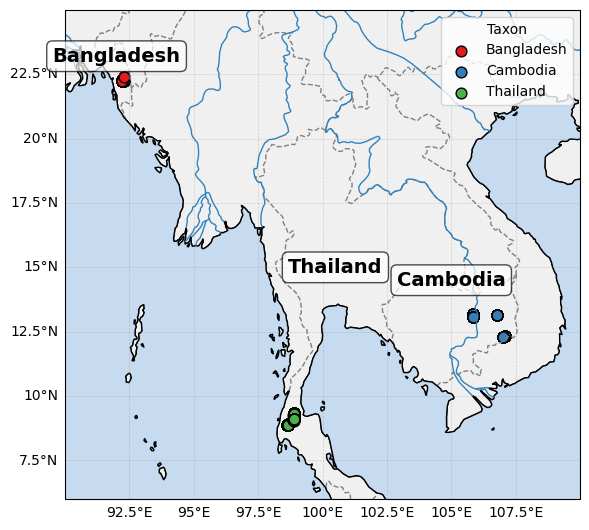

In [10]:
# Plot map for all samples
region_bbox = [90, 110, 6, 25]
plot_sample_map(region_bbox, df_samples, 'country')